Visualize generated, ground-truth trajectories (w/o accompanying predictions)


Imports

In [7]:
import os
from src.data_utils import unpickle_data
from src.analysis_utils import get_sim, plot_line, plot_label_cdw_order_autocorrelation, PLTArgs
from src.physics import calc_charge_order, calc_lattice_order
from src.utils import get_project_root

PROJECT_ROOT = get_project_root()

Arguments

In [8]:
# Path to *.pkl data
data_path: str | os.PathLike = PROJECT_ROOT / "data/generated/L-32-g_0p5_0p8-rd-1e-04-si_64-steps_1200-zero_mom-MID/pickled/test.pkl"

# number of batches to keep. None to keep all
n_batches: int | None = None

# Which steps to start and end on. Use None to not set a restriction (use whole thing)
sim_start: int | None = None
sim_end: int | None = None

Get dataset and restrict batch/time

In [9]:
data = unpickle_data(data_path)
data = [comp[:n_batches, sim_start:sim_end] for comp in data]
print("Number of batches: ", len(data[0]))
print("Number of steps: ", len(data[0][0]))

Number of batches:  64
Number of steps:  1201


Plot Statistical Autocorr

Label charge order autocorr traj [Group Post-Averaged] :


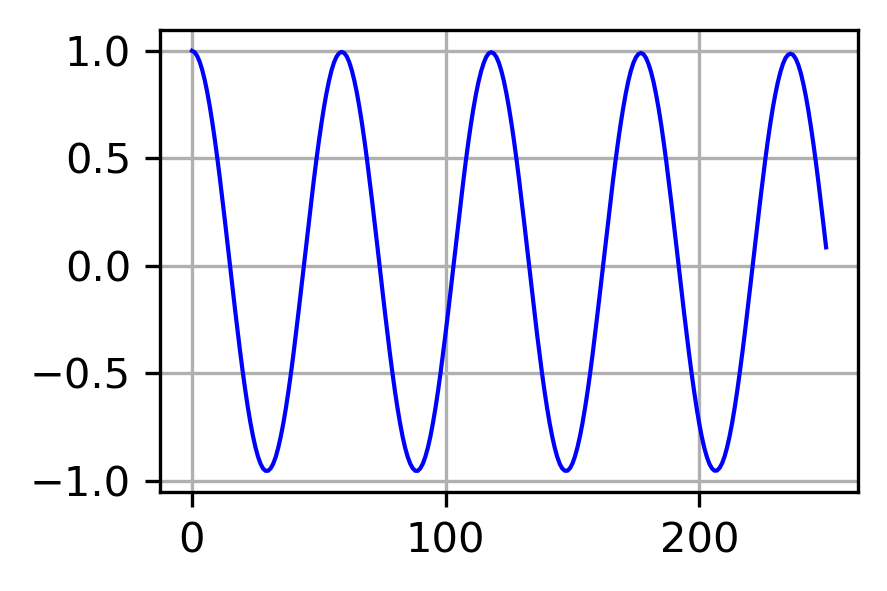

Label lattice order autocorr traj [Group Post-Averaged] :


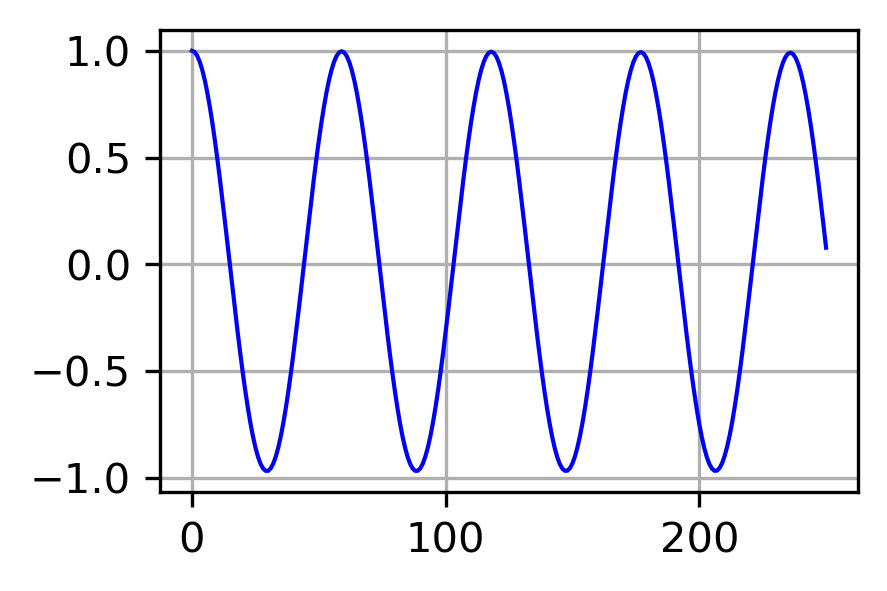

In [10]:
max_lag: int = 250

pltargs = PLTArgs(figsize=(3, 2), dpi=300, disable_text=True, labelsize=10, linewidth=1)

plot_label_cdw_order_autocorrelation(labels=data, max_lag=max_lag, pltargs=pltargs)

Analyze Individual Simulation

In [11]:
sim_idx: int = 0

rho, Q, P = get_sim(data=data, sim_idx=sim_idx)

Plot Values

Charge Order :


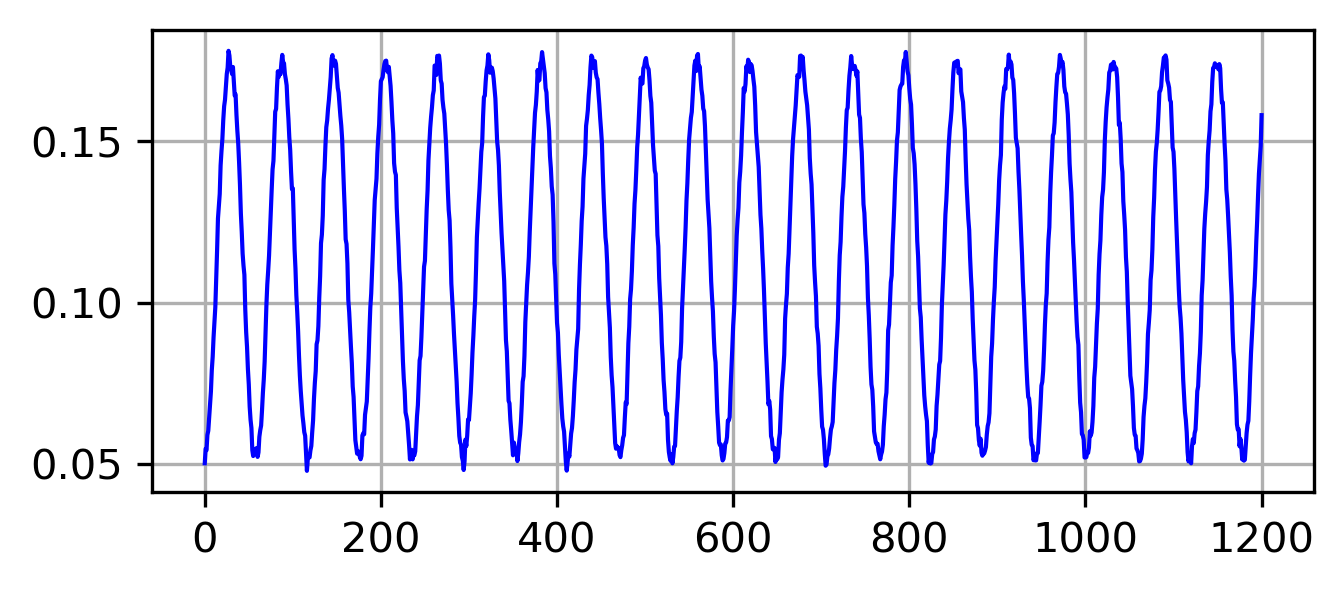

Lattice Order :


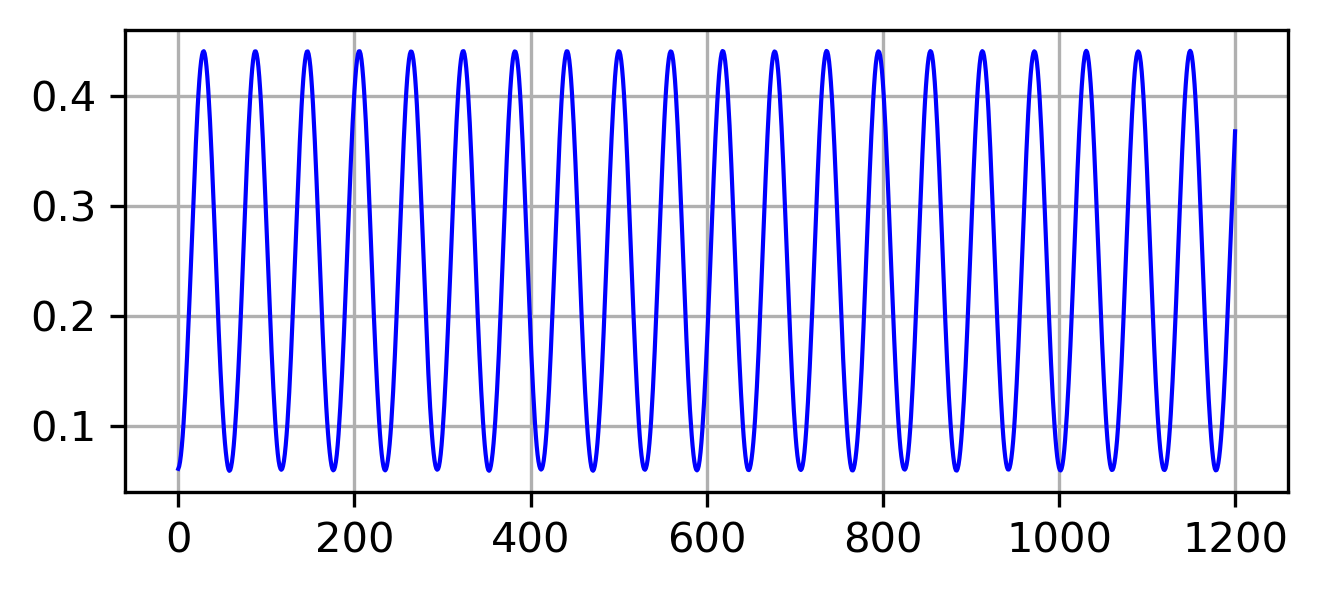

rho site 0 :


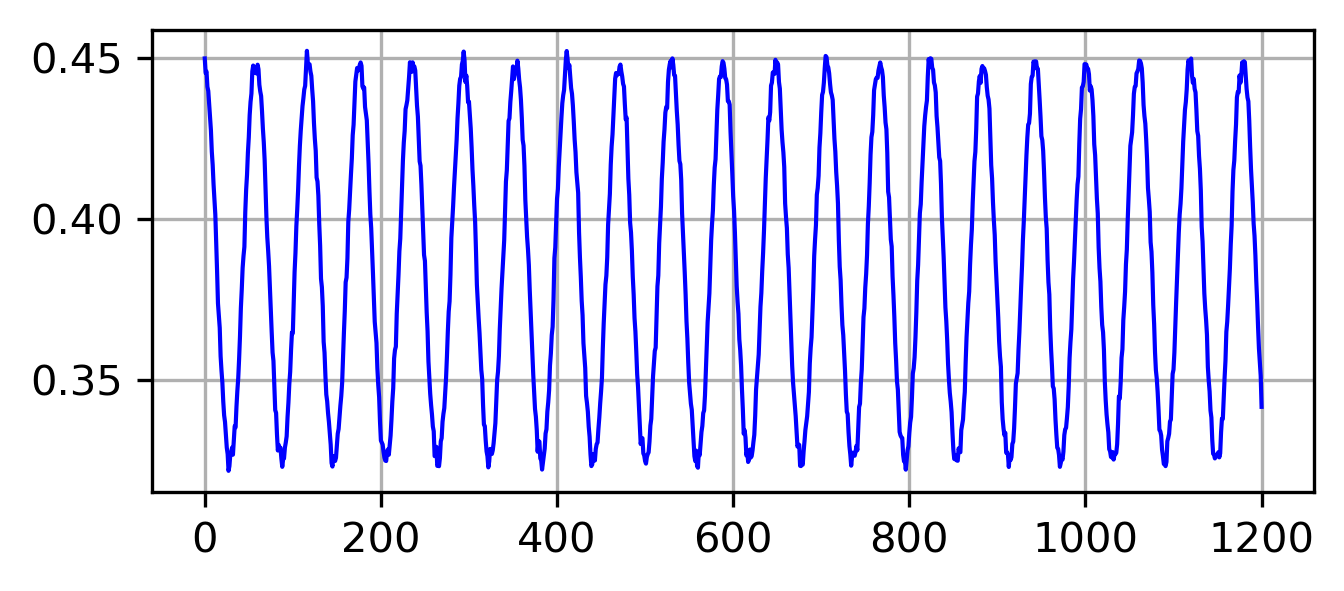

rho site 1 :


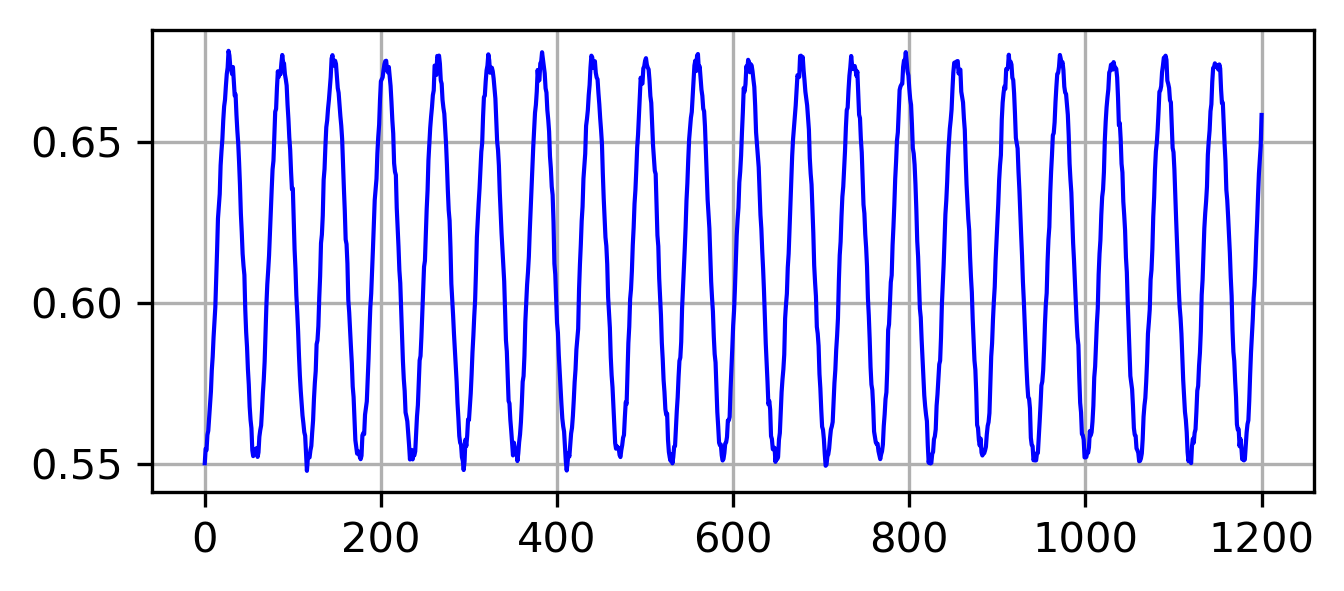

Q site 0 :


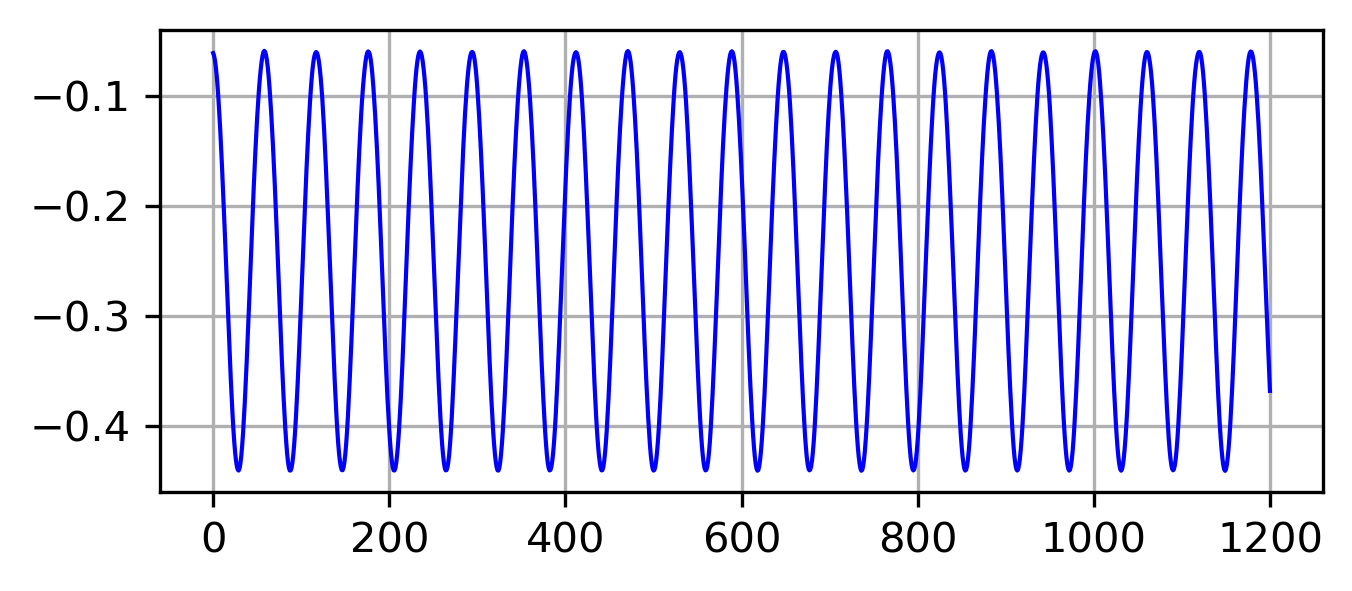

Q site 1 :


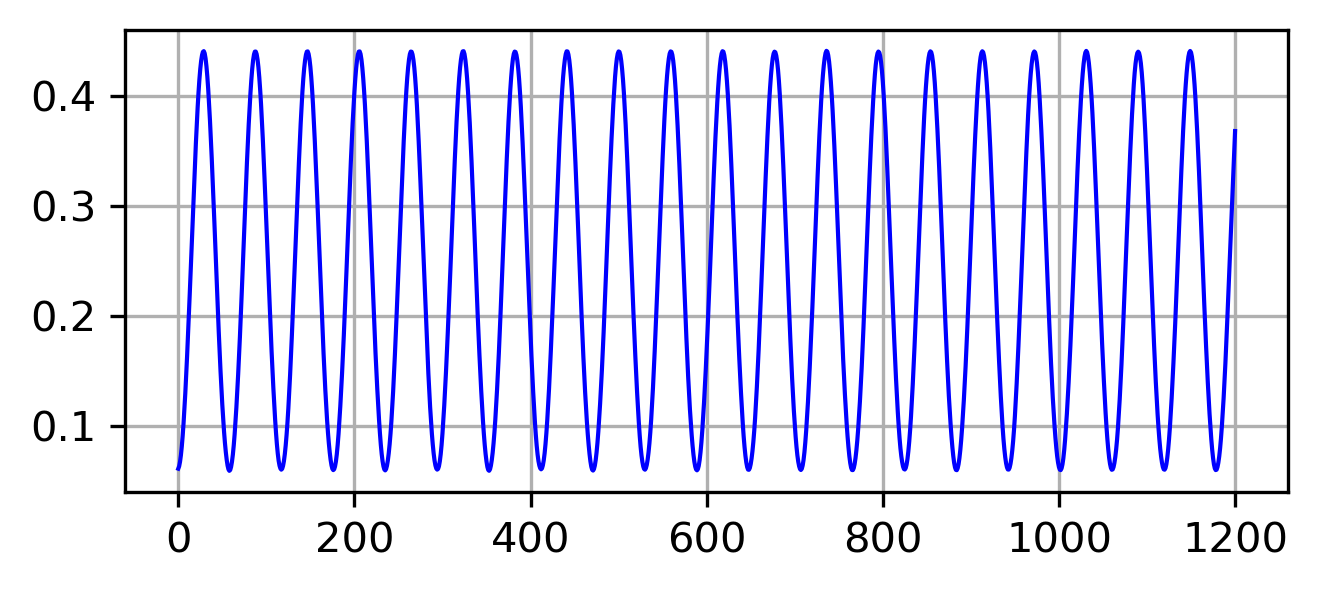

P site 0 :


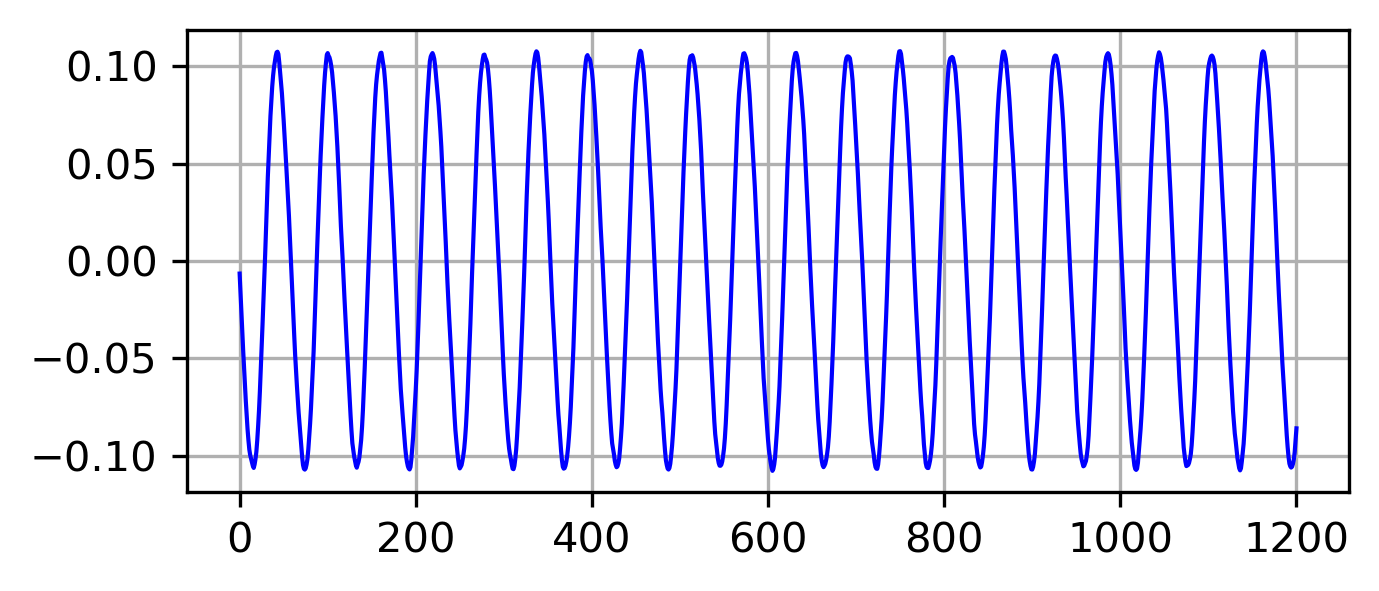

P site 1 :


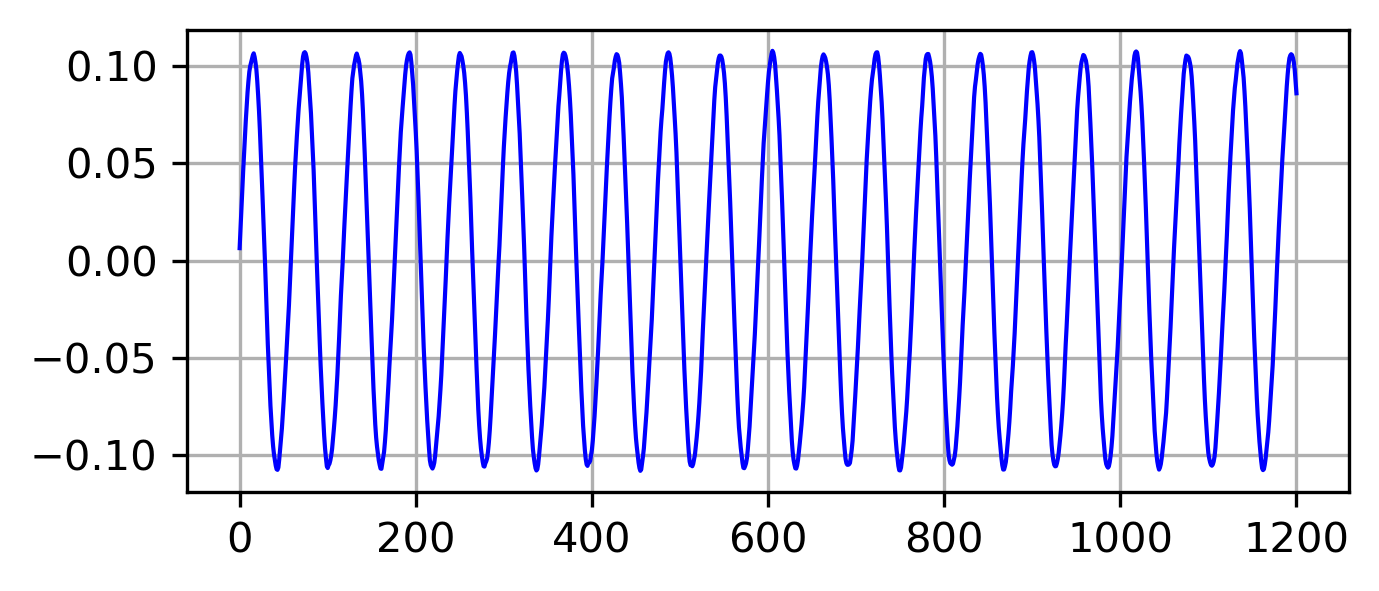

In [12]:
pltargs = PLTArgs(figsize=(5,2), dpi=300, disable_text=True, labelsize=10, linewidth=1)

charge_order = calc_charge_order(rho)
lattice_order = calc_lattice_order(Q)

plot_line(charge_order, "Charge Order", **vars(pltargs))
plot_line(lattice_order, "Lattice Order", **vars(pltargs))

## Plot site values for rho, Q, P on sites 0 and 1

rho_site_0 = rho.real[..., 0, 0]
rho_site_1 = rho.real[..., 1, 1]

Q_site_0 = Q[..., 0]
Q_site_1 = Q[..., 1]

P_site_0 = P[..., 0]
P_site_1 = P[..., 1]

plot_line(rho_site_0, "rho site 0", **vars(pltargs))
plot_line(rho_site_1, "rho site 1", **vars(pltargs))
plot_line(Q_site_0, "Q site 0", **vars(pltargs))
plot_line(Q_site_1, "Q site 1", **vars(pltargs))
plot_line(P_site_0, "P site 0", **vars(pltargs))
plot_line(P_site_1, "P site 1", **vars(pltargs))


Autocorr

Label charge order autocorr traj :


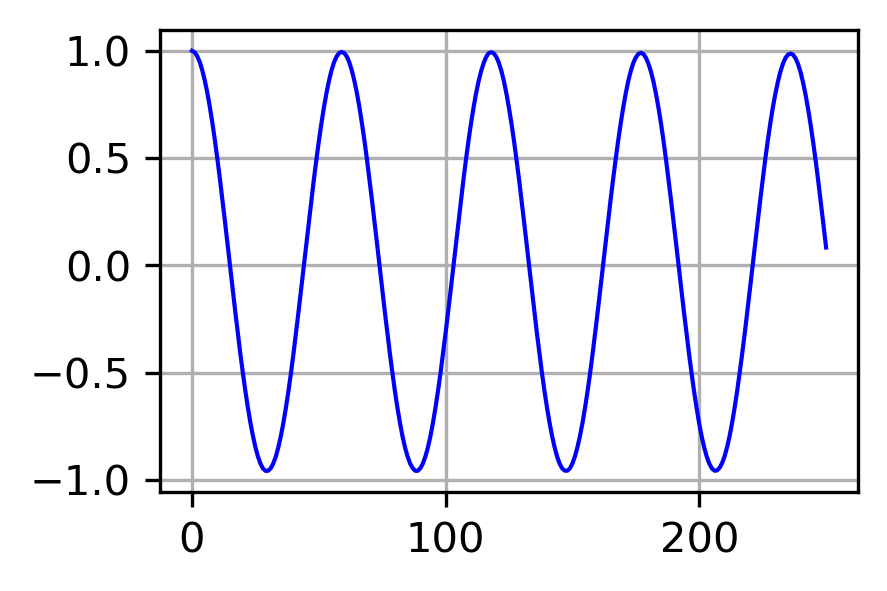

Label lattice order autocorr traj :


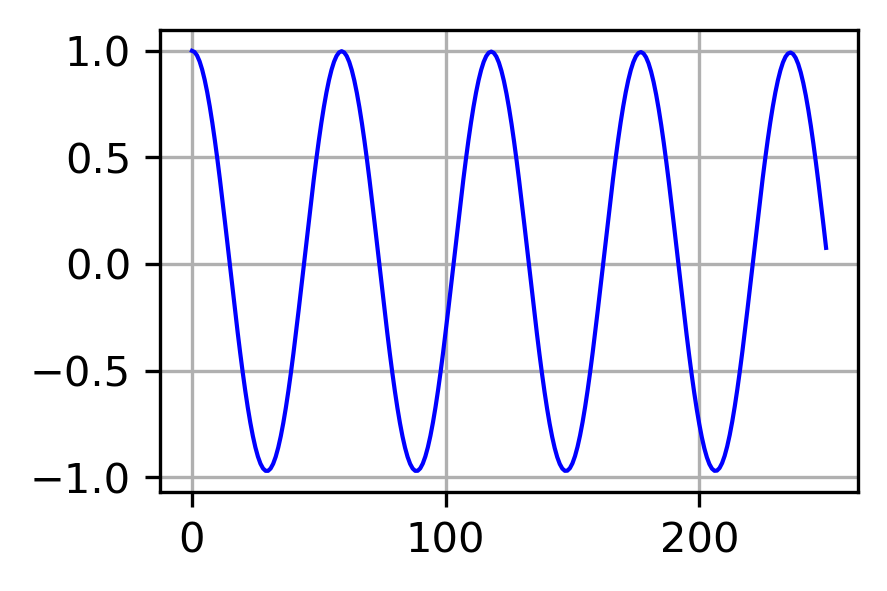

In [13]:
max_lag:int = 250

pltargs = PLTArgs(figsize=(3, 2), dpi=300, disable_text=True, labelsize=10, linewidth=1)

plot_label_cdw_order_autocorrelation((rho, Q, P), max_lag=max_lag, pltargs=pltargs)